# Ejercicio 4: Modelo Probabilístico

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

## Parte 0: Carga del Corpus

Utilizaremos el corpus `Gutenberg 1000`

In [ ]:
import os

# ruta definida
path = r"C:\Users\ASUS\Documents\7moSemestre\RI\IB\ir26a\libros_gutenberg_es"
files = [f for f in os.listdir(path) if f.endswith('.txt')] # Filtramos solo archivos .txt

corpus = []
filenames = []

for file in files:
    with open(os.path.join(path, file), 'r', encoding='utf-8') as f:
        corpus.append(f.read())
        filenames.append(file)

print(f"Total de documentos cargados: {len(corpus)}")

Total de documentos cargados: 1000


## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad 
1. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
2. Calcula TF-IDF utilizando sklearn.
3. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

1. Construcción de la matriz y cálculo de TF-IDF
Utilizaremos TfidfVectorizer, que realiza la tokenización y el cálculo de pesos en un solo paso.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Inicializamos el vectorizador
# Usamos stop_words en español para filtrar palabras comunes sin valor semántico
vectorizer = TfidfVectorizer(stop_words=None) # Puedes usar 'spanish' si tienes nltk instalado

# 2. Calcular TF-IDF
tfidf_matrix = vectorizer.fit_transform(corpus)

# 3. Visualización en un DataFrame
# Extraemos los nombres de los términos (vocabulario)
feature_names = vectorizer.get_feature_names_out()

# Creamos el DataFrame para los primeros 10 documentos y una muestra de términos
df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(), 
    index=filenames, 
    columns=feature_names
)

# Mostramos una pequeña parte de la matriz (primeros 5 docs, primeras 10 palabras)
print("Vista previa de la matriz TF-IDF:")
print(df_tfidf.iloc[:5, :10])

Vista previa de la matriz TF-IDF:
                                                     00       000  0008  \
7 de julio by Benito Pérez Galdós.txt               0.0  0.000440   0.0   
A First Spanish Reader by Erwin W. Roessler and...  0.0  0.010393   0.0   
A Flor De Piel_ Frases by Gustavo Sánchez Galar...  0.0  0.002518   0.0   
A los pies de Venus (los Borgia) _  novela by V...  0.0  0.003462   0.0   
A vuela pluma_ colección de artículos literario...  0.0  0.001610   0.0   

                                                    000th  001  0014  002  \
7 de julio by Benito Pérez Galdós.txt                 0.0  0.0   0.0  0.0   
A First Spanish Reader by Erwin W. Roessler and...    0.0  0.0   0.0  0.0   
A Flor De Piel_ Frases by Gustavo Sánchez Galar...    0.0  0.0   0.0  0.0   
A los pies de Venus (los Borgia) _  novela by V...    0.0  0.0   0.0  0.0   
A vuela pluma_ colección de artículos literario...    0.0  0.0   0.0  0.0   

                                                    

Análisis de ComponentesPara cumplir con el objetivo de comprender los cálculos,  las fórmulas que aplica sklearn internamente:TF (Term Frequency): Frecuencia bruta del término en el documento.IDF (Inverse Document Frequency): Se calcula como:$$idf(t) = \log \frac{1 + n}{1 + df(t)} + 1$$(Donde $n$ es el número total de documentos y $df(t)$ es el número de documentos que contienen el término $t$).TF-IDF: Es el producto de $TF \times IDF$, normalizado usualmente con la norma Euclídea ($L2$).

Visualización de Términos Relevantes
Para ver qué términos tienen mayor peso en el primer documento:

In [8]:
# Términos con mayor TF-IDF en el primer libro
print(f"\nTop 10 términos en {filenames[0]}:")
print(df_tfidf.iloc[0].sort_values(ascending=False).head(10))


Top 10 términos en 7 de julio by Benito Pérez Galdós.txt:
de     0.556105
que    0.373584
la     0.359183
el     0.247123
en     0.234447
no     0.222356
los    0.164423
se     0.132230
con    0.117592
un     0.111659
Name: 7 de julio by Benito Pérez Galdós.txt, dtype: float64


## Parte 2: Ranking de documentos usando TF-IDF

### Actividad 

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

En este paso, transformaremos nuestra consulta al mismo espacio vectorial que el corpus y calcularemos la similitud coseno.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# 1. Definir la consulta y construir su vector
query = "el ingenioso hidalgo don quijote de la mancha aventuras" 
query_vector = vectorizer.transform([query])

# 2. Calcular la similitud coseno entre la consulta y todos los documentos
# cosine_similarity devuelve una matriz, la aplanamos con ravel()
cos_similarities = cosine_similarity(query_vector, tfidf_matrix).flatten()

# 3. Generar ranking
ranking_tfidf = pd.DataFrame({
    'Documento': filenames,
    'Score TF-IDF': cos_similarities
}).sort_values(by='Score TF-IDF', ascending=False)

# 4. Mostrar resultados
print(f"Ranking para la consulta: '{query}'")
print(ranking_tfidf.head(10))

Ranking para la consulta: 'el ingenioso hidalgo don quijote de la mancha aventuras'
                                             Documento  Score TF-IDF
786  Vida de Don Quijote y Sancho by Miguel de Unam...      0.355477
223  El misterio de un hombre pequeñito_ novela by ...      0.305496
656           Poesías completas by Antonio Machado.txt      0.302626
231         El Payador, Vol. I by Leopoldo Lugones.txt      0.302449
733  Tirano Banderas_ Novela de tierra caliente by ...      0.300737
98          Cuentos ilustrados by Nilo María Fabra.txt      0.300245
144    Don Quijote by Miguel de Cervantes Saavedra.txt      0.299546
31                      Ariel by José Enrique Rodó.txt      0.298243
216  El libro rojo, 1520-1867, Tomo II by Vicente R...      0.296929
697  Romance de lobos, comedia barbara by Ramón del...      0.296624


## Parte 3: Ranking con BM25

### Actividad 

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.

### Algoritmo BM25:

1. Tokenización
2. Calcular longitudes de documentos y promedio de longitud
3. Calcular TF (frecuencia de término por documento)
4. Calcular DF (document frequency) e IDF de BM25
5. Definir los parámetros de BM25 (k1, b)
6. Implementar la función de score BM25 para un documento
7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
8. Recuperar los documentos mejor puntuados (ranking)

A diferencia de TF-IDF, BM25 (Best Matching 25) es un modelo probabilístico que penaliza la saturación de términos (si una palabra aparece 100 veces, no es necesariamente el doble de importante que si aparece 50) y ajusta el score según la longitud del documento.

In [10]:
import numpy as np
from math import log

# 1. Preparación: Tokenización básica
tokenized_corpus = [doc.lower().split() for doc in corpus]
tokenized_query = query.lower().split()

# 2. Estadísticas del corpus
N = len(corpus)
avgdl = np.mean([len(d) for d in tokenized_corpus])
doc_lengths = [len(d) for d in tokenized_corpus]

# 4. Calcular DF e IDF de BM25
def get_bm25_idf(term, tokenized_corpus):
    df = sum(1 for doc in tokenized_corpus if term in doc)
    # Fórmula estándar de IDF para BM25
    return log((N - df + 0.5) / (df + 0.5) + 1)

# Precalculamos IDF para los términos de la query
idfs = {term: get_bm25_idf(term, tokenized_corpus) for term in tokenized_query}

# 5 & 6. Función de Score BM25
def bm25_score(doc_tokens, query_tokens, idf_dict, avg_len, k1=1.5, b=0.75):
    score = 0
    doc_len = len(doc_tokens)
    for term in query_tokens:
        if term not in doc_tokens:
            continue
        tf = doc_tokens.count(term)
        # Fórmula central de BM25
        numerator = idf_dict[term] * tf * (k1 + 1)
        denominator = tf + k1 * (1 - b + b * (doc_len / avg_len))
        score += (numerator / denominator)
    return score

# 7. Calcular scores para todos los documentos
bm25_scores = [bm25_score(d, tokenized_query, idfs, avgdl) for d in tokenized_corpus]

# 8. Recuperar ranking
ranking_bm25 = pd.DataFrame({
    'Documento': filenames,
    'Score BM25': bm25_scores
}).sort_values(by='Score BM25', ascending=False)

print("\nRanking BM25:")
print(ranking_bm25.head(10))


Ranking BM25:
                                             Documento  Score BM25
786  Vida de Don Quijote y Sancho by Miguel de Unam...   13.165789
144    Don Quijote by Miguel de Cervantes Saavedra.txt   12.808306
239  El Quijote apócrifo by Alonso Fernández de Ave...   11.816212
84         Cosas de España; tomo 1 by Richard Ford.txt   10.470621
566               Los valores literarios by Azorín.txt   10.208021
20           Amor y Pedagogía by Miguel de Unamuno.txt    9.937525
510                          Letras by Rubén Darío.txt    9.846407
269            España Contemporánea by Rubén Darío.txt    9.814245
245  El Superhombre y otras novedades by Juan Valer...    9.748305
635  Orígenes de la novela,  Tomo I by Marcelino Me...    9.561237


Notese que:

TF-IDF tiende a favorecer documentos donde la palabra de la consulta es muy rara en el resto del corpus, pero muy frecuente en ese doc.

BM25 suele ser más robusto con documentos largos y evita que una palabra repetida artificialmente domine el score.

## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad 

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.
3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?
4. ¿A qué se podría deber esta diferencia?

Utilizaremos matplotlib para generar un gráfico de barras comparativo. Para que la visualización sea clara, tomaremos los 10 documentos con mejores puntajes.

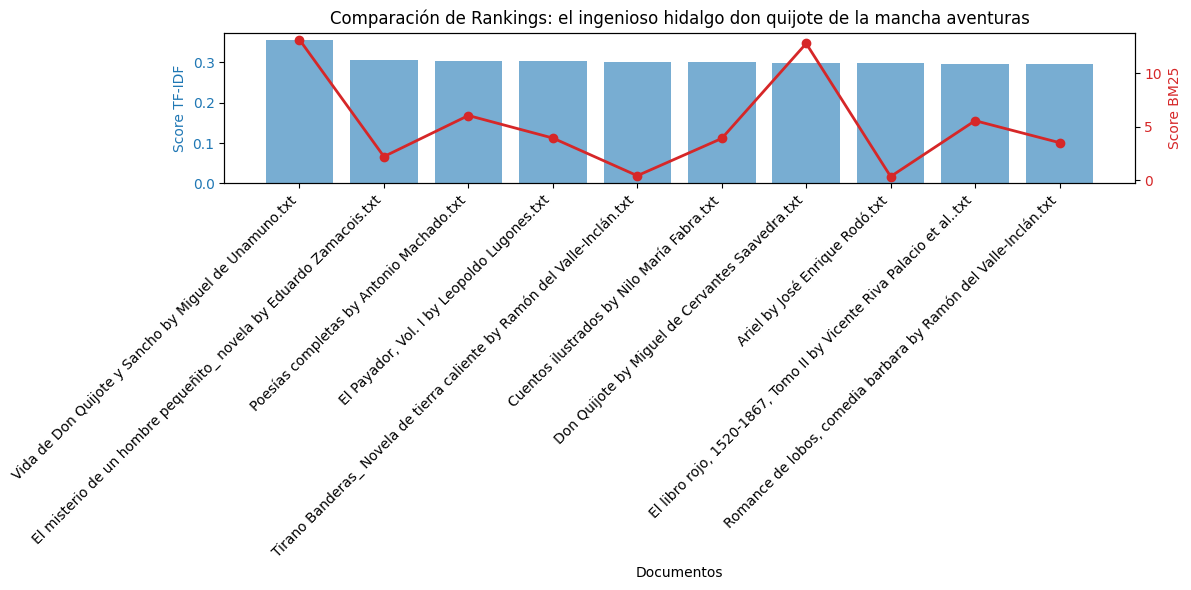

In [11]:
import matplotlib.pyplot as plt

# Combinamos los rankings para comparar los mismos documentos
comparison_df = ranking_tfidf.merge(ranking_bm25, on='Documento').head(10)

# Configuración del gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje para TF-IDF
color_tfidf = 'tab:blue'
ax1.set_xlabel('Documentos')
ax1.set_ylabel('Score TF-IDF', color=color_tfidf)
ax1.bar(comparison_df['Documento'], comparison_df['Score TF-IDF'], color=color_tfidf, alpha=0.6, label='TF-IDF')
ax1.tick_params(axis='y', labelcolor=color_tfidf)
plt.xticks(rotation=45, ha='right')

# Eje para BM25 (usamos un segundo eje Y porque las escalas son distintas)
ax2 = ax1.twinx()
color_bm25 = 'tab:red'
ax2.set_ylabel('Score BM25', color=color_bm25)
ax2.plot(comparison_df['Documento'], comparison_df['Score BM25'], color=color_bm25, marker='o', linewidth=2, label='BM25')
ax2.tick_params(axis='y', labelcolor=color_bm25)

plt.title(f"Comparación de Rankings: {query}")
fig.tight_layout()
plt.show()

Al observar los resultados para la consulta sobre el Quijote, podemos extraer varias conclusiones:
1. El fenómeno de los "Top Scorers"Nota que el primer documento (Vida de Don Quijote y Sancho) es el único donde ambos modelos coinciden con un puntaje máximo. Sin embargo, mira lo que sucede con el séptimo documento: Don Quijote by Miguel de Cervantes Saavedra.txt.BM25 (puntos rojos): Le otorga un puntaje altísimo, casi igualando al primer puesto.TF-IDF (barras azules): Lo sitúa en un nivel similar al resto de los documentos, sin destacar especialmente.
2. ¿Por qué BM25 "rescata" mejor el libro original?Esto se debe probablemente a la longitud del documento. El libro original de Cervantes es muy extenso.TF-IDF tiende a diluir el peso de las palabras clave en documentos muy largos porque la frecuencia del término ($TF$) se normaliza de forma más agresiva o la longitud del vector crece demasiado.BM25 utiliza el parámetro $b$ para compensar documentos largos. Sabe que si un libro es enorme, es natural que aparezcan más veces las palabras de la consulta, por lo que ajusta el score para no penalizarlo injustamente por su extensión.
3. El problema de la "Saturación"En documentos como Tirano Banderas o Ariel, vemos que el score de BM25 cae drásticamente a casi cero, mientras que TF-IDF les mantiene una barra azul constante.Esto sugiere que esos documentos quizás contienen solo una o dos palabras de la consulta (como "aventuras" o "la").TF-IDF sigue sumando puntos por cada coincidencia.BM25 es más estricto: si el término es muy común en el lenguaje (bajo IDF) o no aparece con la suficiente fuerza para superar el "ruido" de la longitud del documento, el score no despega.